In [77]:
import numpy as np
import cv2
from paddleocr import PaddleOCR
import matplotlib.pyplot as plt
import time

In [78]:
ocr = PaddleOCR(lang='en', enable_mkldnn=False, use_doc_orientation_classify=False, use_doc_unwarping=False, use_textline_orientation=False, device="gpu")

Creating model: ('PP-OCRv6_medium_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/vhvhs/.paddlex/official_models/PP-OCRv6_medium_det`.


Creating model: ('PP-OCRv6_medium_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/vhvhs/.paddlex/official_models/PP-OCRv6_medium_rec`.


In [79]:
def extract_ROI(image, bboxes, debug):
    ROI = []
    for bbox in bboxes:
        x_min, y_min, x_max, y_max = map(int, bbox)
        if debug:
                print("bbox = ", bbox)
                print(f"x = ({x_min}, {x_max})\ny = ({y_min}, {y_max})"
                )
        ROI.append(image[y_min: y_max, x_min: x_max])
    return ROI

In [80]:
panel = cv2.imread('/home/vhvhs/MirrorMyManga/testFolder4/testImage4.png')
panel = np.asarray(panel)

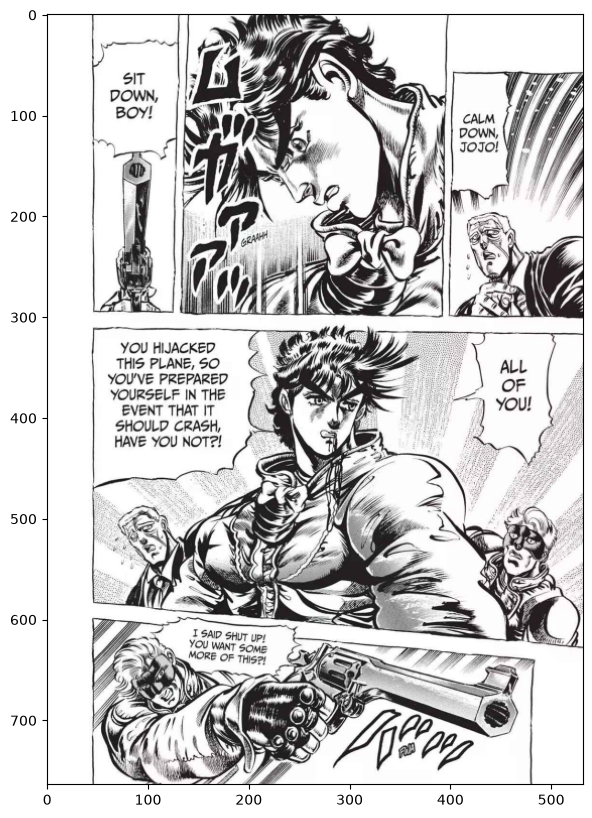

In [81]:
plt.figure(figsize=(20, 10))
plt.imshow(cv2.cvtColor(panel, cv2.COLOR_BGR2RGB))
plt.show()

In [ ]:
def transform(panel, show_logs=False):
        """
            Applies the flipped ROI to the to the detect text ROIs, flips the whole panel then returns the panel
        """
        panel = np.asarray(panel)
        height, width = np.asarray(panel).shape[:2]
        new_height, new_width = height, width
        aspect_ratio = 1
        start = time.perf_counter()

        #if the width is too large than simply get a scaled down copy of the 
        #OG panel and perform operations on it
        if width > 1500:
            new_width = 1500
            aspect_ratio = new_width / width
            new_height = int(height * aspect_ratio)

        if show_logs:
            print("old: ", height, width, aspect_ratio)
            print("new: ", new_height, new_width, aspect_ratio)

        panel_small = cv2.resize(panel, dsize=(new_width, new_height))

        #detected text and 
        result = ocr.predict(panel_small, use_doc_orientation_classify=False, use_doc_unwarping=False, use_textline_orientation=False)
        bboxes = dict(result[0])['rec_boxes']
        text = dict(result[0])['rec_texts']

        #scaling back the bboxes to the OG resolution format
        bboxes = bboxes / aspect_ratio
        bboxes = bboxes.astype(np.uint16)
        
        sorted_bboxes = bboxes[np.argsort(bboxes[:, 1])]
        groupped_bboxes = []
        merge_bboxes_list = []
        for i, sorted_bbox in enumerate(sorted_bboxes):
            if i + 1 == sorted_bboxes.shape[0]:
                break
            
            x_min, y_min, x_max, y_max = map(int, sorted_bbox)
            #print(f"x_min, x_max = {x_min}, {x_max}")
            #print(f"y_min, y_max = {y_min}, {y_max}")
        
            temp_list = []
            #if the difference between y_max of ith and y_min of  is equal to 0(two bboxes are tangential) or more than zero(two bboxes are overlapping)
            #add them in temp_list
            print(f" sorted_bboxes[{i + 1}][1] - sorted_bboxes[{i}][3]= {sorted_bboxes[i + 1][1]} - {sorted_bboxes[i][3]}")
            if 1 >= sorted_bboxes[i][3] - sorted_bboxes[i + 1][1] >= 0:
                temp_list.append(sorted_bboxes[i])
                temp_list.append(sorted_bboxes[i+1])
                merge_bboxes_list.append(temp_list)
        
        for merge_bboxes in merge_bboxes_list:
            #now append only the min(x_max), y_min of 0th element and max(x_max), y_max of last element in clustered bboxes
            merge_bboxes = np.asarray(merge_bboxes)
            local_x_min = np.min(merge_bboxes[:, 0])
            local_x_max = np.max(merge_bboxes[:, 2])
            groupped_bboxes.append([local_x_min, merge_bboxes[0][1], local_x_max, merge_bboxes[-1][3]])
        
        flipped_panel = np.fliplr(panel)
        for bbox in groupped_bboxes:
            x_min, y_min, x_max, y_max = map(int, bbox)
            mirror_x_max, mirror_x_min = (new_width - x_min, new_width - x_max)

            flipped_panel[y_min: y_max, mirror_x_min: mirror_x_max] = panel[y_min: y_max, x_min: x_max]

        if show_logs:
            print("processing time: ", time.perf_counter() - start)
        return flipped_panel, bboxes

panel, bboxes = transform(panel=panel, show_logs=True)

old:  764 532 1
new:  764 532 1
x_min, x_max = 128, 222
y_min, y_max = 14, 295
mirror_x_min, mirror_x_max = 310, 404
filpped panel array  [[[146 ... 146]
  ...
  [253 ... 253]]

 ...

 [[251 ... 251]
  ...
  [255 ... 255]]]
x_min, x_max = 70, 101
y_min, y_max = 50, 74
mirror_x_min, mirror_x_max = 431, 462
filpped panel array  [[[255 ... 255]
  ...
  [255 ... 255]]

 ...

 [[251 ... 251]
  ...
  [248 ... 248]]]
x_min, x_max = 60, 111
y_min, y_max = 71, 89
mirror_x_min, mirror_x_max = 421, 472
filpped panel array  [[[255 ... 255]
  ...
  [255 ... 255]]

 ...

 [[251 ... 251]
  ...
  [255 ... 255]]]
x_min, x_max = 65, 108
y_min, y_max = 88, 105
mirror_x_min, mirror_x_max = 424, 467
filpped panel array  [[[255 ... 255]
  ...
  [252 ... 252]]

 ...

 [[255 ... 255]
  ...
  [255 ... 255]]]
x_min, x_max = 411, 447
y_min, y_max = 95, 109
mirror_x_min, mirror_x_max = 85, 121
filpped panel array  [[[253 ... 253]
  ...
  [253 ... 253]]

 ...

 [[252 ... 252]
  ...
  [253 ... 253]]]
x_min, x_max =

In [83]:
#i = 0
#for roi in ROI:
#    if i < 5:
#        plt.imshow(roi)
#        plt.show()
#        i += 1

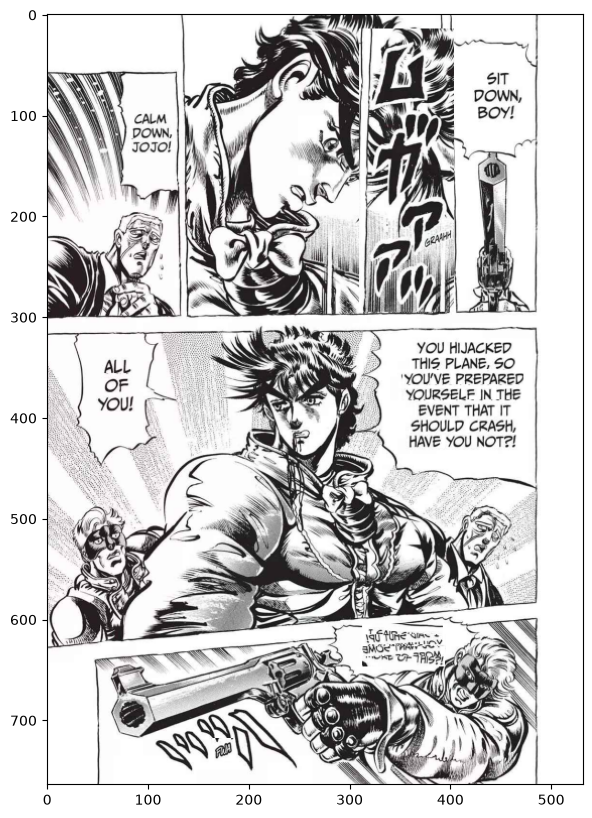

In [ ]:
plt.figure(figsize=(20, 10))
plt.imshow(cv2.cvtColor(panel, cv2.COLOR_BGR2RGB))
plt.show()